# Precompute Swing Thresholds

Sweeps a grid of `(pA, pB)` pairs and writes per-set swing quantiles to
`data/swing_thresholds.db`.  The trading bot reads that file via
`trade/swing_thresholds.py` to set its per-game entry threshold dynamically,
rather than using the old static `MIN_GAME_SWING` config.

**Run time:** ~30–60 min at `N_MATCHES = 20_000`.  
Set `N_MATCHES = 5_000` for a quicker first pass (~8–15 min).

**Idempotent:** uses `INSERT OR REPLACE`, so re-running just overwrites existing rows.

In [1]:
import sys, time, sqlite3
from collections import defaultdict

import numpy as np

sys.path.insert(0, r"D:\CMU\Kalshi\Tennis Monte Carlo")
import trade.exact as E

## Parameters

- `PA_GRID` / `PB_GRID`: serve-win probability grids (0.55–0.75, step 0.01)
- `N_MATCHES`: Monte Carlo matches per `(pA, pB, best_of)` cell
- `KEEP_PCTS`: quantile levels stored — one column per level; bot picks the one matching `KEEP_FRACTION` in config
- `DB_PATH`: output SQLite file

In [2]:
PA_GRID   = [round(0.55 + i * 0.01, 2) for i in range(21)]   # 0.55 … 0.75
PB_GRID   = [round(0.55 + i * 0.01, 2) for i in range(21)]
N_MATCHES = 1_000
KEEP_PCTS = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
DB_PATH   = r"D:\CMU\Kalshi\Tennis Monte Carlo\data\swing_thresholds_test.db"

print(f"Grid: {len(PA_GRID)}×{len(PB_GRID)} = {len(PA_GRID)*len(PB_GRID)} pairs")
print(f"Combos (×2 best_of): {len(PA_GRID)*len(PB_GRID)*2}")
print(f"Matches per combo: {N_MATCHES:,}")
print(f"Output: {DB_PATH}")

Grid: 21×21 = 441 pairs
Combos (×2 best_of): 882
Matches per combo: 1,000
Output: D:\CMU\Kalshi\Tennis Monte Carlo\data\swing_thresholds_test.db


## Simulation Engine

Mirrors the engine in `game_swing_by_set.ipynb`.  Outcomes are drawn from the
exact DP game-win probability, so results are consistent with the model.

In [3]:
class Engine:
    """Memoised DP values at game boundaries for one (pA, pB, best_of) triple."""
    def __init__(self, pA, pB, best_of):
        self.pA, self.pB, self.bo = pA, pB, best_of
        self._v, self._g = {}, {}

    def swing(self, sets, games, p1_serves, tb):
        key = (sets, games, p1_serves, tb)
        if key not in self._v:
            r = E.win_probs(np.array([self.pA]), np.array([self.pB]),
                            sets, games, tb, (0, 0), p1_serves, self.bo)
            self._v[key] = abs(float(r["cond"]["win_game"][0])
                               - float(r["cond"]["lose_game"][0]))
        return self._v[key]

    def hold(self, p1_serves):
        if p1_serves not in self._g:
            self._g[p1_serves] = E.game_win_prob(self.pA if p1_serves else self.pB)
        return self._g[p1_serves]


def set_over(g):
    hi, lo = max(g), min(g)
    return (hi >= 6 and hi - lo >= 2) or hi == 7


def simulate(pA, pB, n_matches, best_of, rng):
    """Return list of (setno, swing) for on-serve, non-tiebreak game boundaries."""
    eng  = Engine(pA, pB, best_of)
    need = best_of // 2 + 1
    recs = []

    for _ in range(n_matches):
        sets      = [0, 0]
        p1_serves = bool(rng.integers(2))
        while max(sets) < need:
            setno = sets[0] + sets[1] + 1
            games = [0, 0]
            while True:
                tb_flag = (games == [6, 6])

                if not tb_flag:
                    sg = games[0] if p1_serves else games[1]
                    rg = games[1] if p1_serves else games[0]
                    on_serve = abs(games[0] - games[1]) <= 1 and sg <= rg
                    if on_serve:
                        recs.append((setno, eng.swing(tuple(sets), tuple(games), p1_serves, False)))

                if tb_flag:
                    p1_win = rng.random() < E.tiebreak_win_prob(pA, pB, a_serves_next=p1_serves)
                    games[0 if p1_win else 1] += 1
                else:
                    holds = rng.random() < eng.hold(p1_serves)
                    if p1_serves:
                        games[0 if holds else 1] += 1
                    else:
                        games[1 if holds else 0] += 1

                p1_serves = not p1_serves
                if set_over(games):
                    break
            sets[0 if games[0] > games[1] else 1] += 1

    return recs

## Database Setup

In [4]:
def init_db(path):
    conn = sqlite3.connect(path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS thresholds (
            pA       REAL    NOT NULL,
            pB       REAL    NOT NULL,
            best_of  INTEGER NOT NULL,
            set_num  INTEGER NOT NULL,
            keep_pct INTEGER NOT NULL,
            threshold REAL   NOT NULL,
            PRIMARY KEY (pA, pB, best_of, set_num, keep_pct)
        )
    """)
    conn.commit()
    return conn


def write_rows(conn, pA, pB, best_of, recs):
    """Compute quantiles from (setno, swing) records and upsert into the DB."""
    by_set = defaultdict(list)
    for setno, sw in recs:
        by_set[setno].append(sw)

    rows = []
    for setno, swings in sorted(by_set.items()):
        arr = np.array(swings)
        for kp in KEEP_PCTS:
            q = round(float(np.quantile(arr, 1.0 - kp / 100.0)), 3)
            rows.append((round(pA, 2), round(pB, 2), best_of, setno, kp, q))

    conn.executemany(
        "INSERT OR REPLACE INTO thresholds "
        "(pA, pB, best_of, set_num, keep_pct, threshold) VALUES (?,?,?,?,?,?)",
        rows,
    )
    conn.commit()

## Run

Outer loop over all `(pA, pB, best_of)` combos.  Progress is printed every row.

In [5]:
rng   = np.random.default_rng(42)
conn  = init_db(DB_PATH)
total = len(PA_GRID) * len(PB_GRID) * 2
done  = 0
t0    = time.time()

for pA in PA_GRID:
    for pB in PB_GRID:
        for best_of in (3, 5):
            recs = simulate(pA, pB, N_MATCHES, best_of, rng)
            write_rows(conn, pA, pB, best_of, recs)
            done += 1
            elapsed = time.time() - t0
            eta     = elapsed / done * (total - done)
            print(f"[{done:>4}/{total}]  pA={pA:.2f} pB={pB:.2f} Bo{best_of}  "
                  f"elapsed {elapsed:6.0f}s  ETA {eta:6.0f}s", flush=True)

conn.close()
elapsed = time.time() - t0
print(f"\nDone in {elapsed/60:.1f} min.  Written to {DB_PATH}")

[   1/882]  pA=0.55 pB=0.55 Bo3  elapsed      0s  ETA    401s
[   2/882]  pA=0.55 pB=0.55 Bo5  elapsed      1s  ETA    653s
[   3/882]  pA=0.55 pB=0.56 Bo3  elapsed      2s  ETA    576s
[   4/882]  pA=0.55 pB=0.56 Bo5  elapsed      3s  ETA    716s
[   5/882]  pA=0.55 pB=0.57 Bo3  elapsed      4s  ETA    673s
[   6/882]  pA=0.55 pB=0.57 Bo5  elapsed      5s  ETA    731s
[   7/882]  pA=0.55 pB=0.58 Bo3  elapsed      5s  ETA    686s
[   8/882]  pA=0.55 pB=0.58 Bo5  elapsed      6s  ETA    709s
[   9/882]  pA=0.55 pB=0.59 Bo3  elapsed      7s  ETA    673s
[  10/882]  pA=0.55 pB=0.59 Bo5  elapsed      8s  ETA    685s
[  11/882]  pA=0.55 pB=0.60 Bo3  elapsed      8s  ETA    657s
[  12/882]  pA=0.55 pB=0.60 Bo5  elapsed      9s  ETA    671s
[  13/882]  pA=0.55 pB=0.61 Bo3  elapsed     10s  ETA    647s
[  14/882]  pA=0.55 pB=0.61 Bo5  elapsed     11s  ETA    661s
[  15/882]  pA=0.55 pB=0.62 Bo3  elapsed     11s  ETA    642s
[  16/882]  pA=0.55 pB=0.62 Bo5  elapsed     12s  ETA    653s
[  17/88

## Verify

In [6]:
import pandas as pd

conn = sqlite3.connect(DB_PATH)
summary = pd.read_sql_query("""
    SELECT best_of, set_num, keep_pct,
           COUNT(*)       AS n_pairs,
           ROUND(MIN(threshold)*100,1) AS min_pp,
           ROUND(AVG(threshold)*100,1) AS avg_pp,
           ROUND(MAX(threshold)*100,1) AS max_pp
    FROM thresholds
    WHERE keep_pct = 30
    GROUP BY best_of, set_num
    ORDER BY best_of, set_num
""", conn)
conn.close()

print("keep_pct=30 summary (threshold in pp)")
print(summary.to_string(index=False))

keep_pct=30 summary (threshold in pp)
 best_of  set_num  keep_pct  n_pairs  min_pp  avg_pp  max_pp
       3        1        30      441     1.9    15.1    24.0
       3        2        30      441     1.0    14.9    24.0
       3        3        30      441    20.1    37.4    48.2
       5        1        30      441     0.3     9.7    17.9
       5        2        30      441     0.1     9.7    17.9
       5        3        30      441     0.1    11.3    21.8
       5        4        30      441     1.0    14.8    24.0
       5        5        30      441    17.8    37.3    48.2


## Heatmaps — threshold (pp) by pA × pB\n\nOne heatmap per set per format, at `keep_pct = 30`.  Axes are the serve-win\nprobabilities; colour is the entry threshold in percentage points."

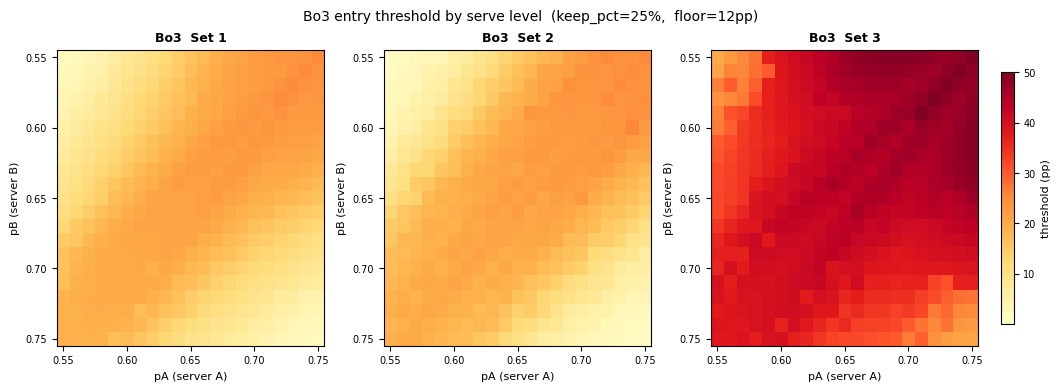

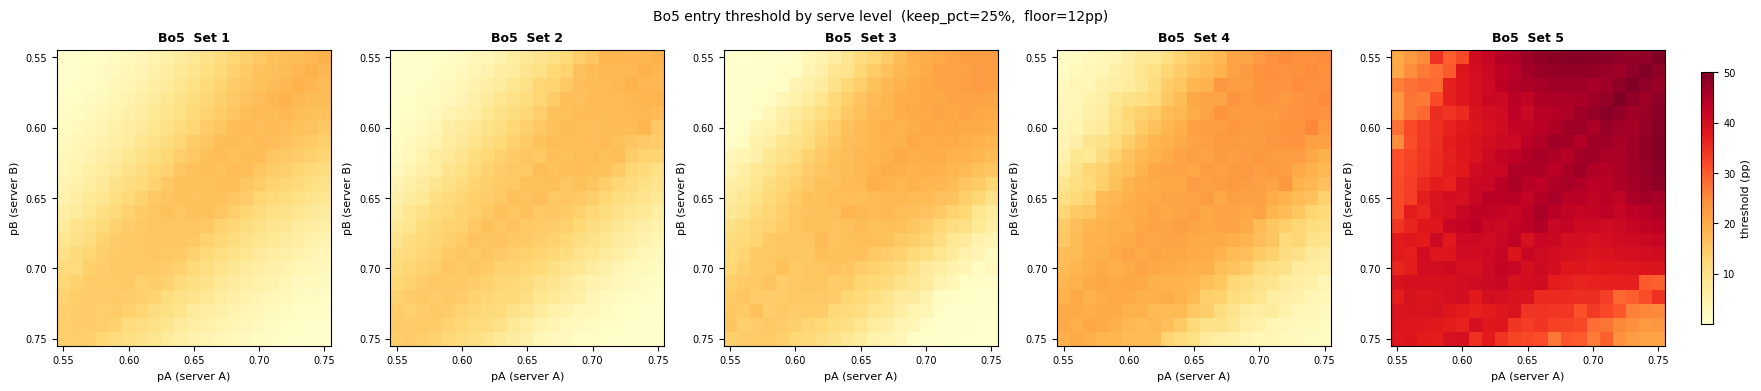

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np, sqlite3, pandas as pd

HEATMAP_KEEP_PCT = 25   # which keep_pct level to visualise

conn = sqlite3.connect(DB_PATH)
df   = pd.read_sql_query(
    "SELECT pA, pB, best_of, set_num, threshold FROM thresholds WHERE keep_pct = ?",
    conn, params=(HEATMAP_KEEP_PCT,)
)
conn.close()

pa_vals = sorted(df.pA.unique())
pb_vals = sorted(df.pB.unique())

def make_heatmap(ax, best_of, set_num):
    sub = df[(df.best_of == best_of) & (df.set_num == set_num)]
    pivot = (sub.pivot(index="pB", columns="pA", values="threshold")
               .reindex(index=pb_vals[::-1], columns=pa_vals))   # pB high→low on y
    data = pivot.values * 100   # convert to pp

    vmin = df.threshold.min() * 100
    vmax = df.threshold.max() * 100
    im = ax.imshow(data, aspect="auto", origin="upper",
                   cmap="YlOrRd", vmin=vmin, vmax=vmax,
                   extent=[-0.5, len(pa_vals) - 0.5, -0.5, len(pb_vals) - 0.5])

    # Axis ticks: show every 5th label to avoid crowding
    step = 5
    xticks = range(0, len(pa_vals), step)
    yticks = range(0, len(pb_vals), step)
    ax.set_xticks(list(xticks))
    ax.set_xticklabels([f"{pa_vals[i]:.2f}" for i in xticks], fontsize=7)
    ax.set_yticks(list(yticks))
    ax.set_yticklabels([f"{pb_vals[::-1][i]:.2f}" for i in yticks], fontsize=7)

    ax.set_xlabel("pA (server A)", fontsize=8)
    ax.set_ylabel("pB (server B)", fontsize=8)
    ax.set_title(f"Bo{best_of}  Set {set_num}", fontsize=9, fontweight="bold")
    return im


for best_of, n_sets in ((3, 3), (5, 5)):
    fig, axes = plt.subplots(1, n_sets, figsize=(3.5 * n_sets, 3.8),
                             constrained_layout=True)
    if n_sets == 1:
        axes = [axes]
    im = None
    for set_num, ax in enumerate(axes, start=1):
        im = make_heatmap(ax, best_of, set_num)

    cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("threshold (pp)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    fig.suptitle(f"Bo{best_of} entry threshold by serve level  "
                 f"(keep_pct={HEATMAP_KEEP_PCT}%,  floor=12pp)",
                 fontsize=10)
    plt.show()

## Ratio & E[ΔP] exploratory analysis

Pure swing (`cond_win − cond_lose`) measures how much a game *moves* match probability, but ignores two things:

1. **Where the current market price sits** relative to those two outcomes
2. **How likely P1 is to win the game** (`g`)

Two derived metrics:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **ratio** | `(cond_win − mkt) / (mkt − cond_lose)` | Payoff asymmetry for a long-P1 bet: >1 is favourable |
| **E[ΔP]** | `g·(cond_win − mkt) − (1−g)·(mkt − cond_lose)` | Expected price change per contract held |

**Important degeneracy at model price:** when `mkt = model_price = g·cond_win + (1−g)·cond_lose`:
- `E[ΔP] = 0` always (price is efficient — no edge by construction)
- `ratio = (1−g)/g` always (just the inverse of game-win odds; <1 for any favoured server)

So both metrics only differentiate situations relative to **market divergence** `δ = model − mkt`.
In fact `E[ΔP] = δ` exactly (swing-independent!).
The ratio is the more interesting quantity: it amplifies divergence differently depending on how wide the swing is.

In [9]:
"""Collect (setno, swing, cond_win, cond_lose, g) at every on-serve game boundary."""
import numpy as np
import trade.exact as E

PA_EX, PB_EX, BO_EX = 0.65, 0.65, 3
N_EX = 100
rng_ex = np.random.default_rng(0)


def _set_over(g):
    hi, lo = max(g), min(g)
    return (hi >= 6 and hi - lo >= 2) or hi == 7


def simulate_full(pA, pB, n_matches, best_of, rng):
    """Like simulate() but records (setno, swing, cond_win, cond_lose, g) per game."""
    need = best_of // 2 + 1
    recs = []

    for _ in range(n_matches):
        sets = [0, 0]
        p1_serves = bool(rng.integers(2))
        while max(sets) < need:
            setno = sets[0] + sets[1] + 1
            games = [0, 0]
            while True:
                tb_flag = games == [6, 6]
                if not tb_flag:
                    sg = games[0] if p1_serves else games[1]
                    rg = games[1] if p1_serves else games[0]
                    on_serve = abs(games[0] - games[1]) <= 1 and sg <= rg
                    if on_serve:
                        r  = E.win_probs(np.array([pA]), np.array([pB]),
                                         tuple(sets), tuple(games), False, (0, 0),
                                         p1_serves, best_of)
                        cw = float(r["cond"]["win_game"][0])
                        cl = float(r["cond"]["lose_game"][0])
                        g  = float(r["game"][0]) if hasattr(r["game"], "__len__") else float(r["game"])
                        recs.append((setno, cw - cl, cw, cl, g))

                # advance the game
                if tb_flag:
                    p1_win = rng.random() < E.tiebreak_win_prob(pA, pB, a_serves_next=p1_serves)
                    games[0 if p1_win else 1] += 1
                else:
                    gp = float(E.game_win_prob(pA if p1_serves else pB))
                    holds = rng.random() < gp
                    if p1_serves:
                        games[0 if holds else 1] += 1
                    else:
                        games[1 if holds else 0] += 1

                p1_serves = not p1_serves
                if _set_over(games):
                    break
            sets[0 if games[0] > games[1] else 1] += 1

    return recs


recs_ex = simulate_full(PA_EX, PB_EX, N_EX, BO_EX, rng_ex)
print(f"Collected {len(recs_ex):,} on-serve game-boundary records "
      f"(Bo{BO_EX}, pA=pB={PA_EX})")

Collected 1,518 on-serve game-boundary records (Bo3, pA=pB=0.65)


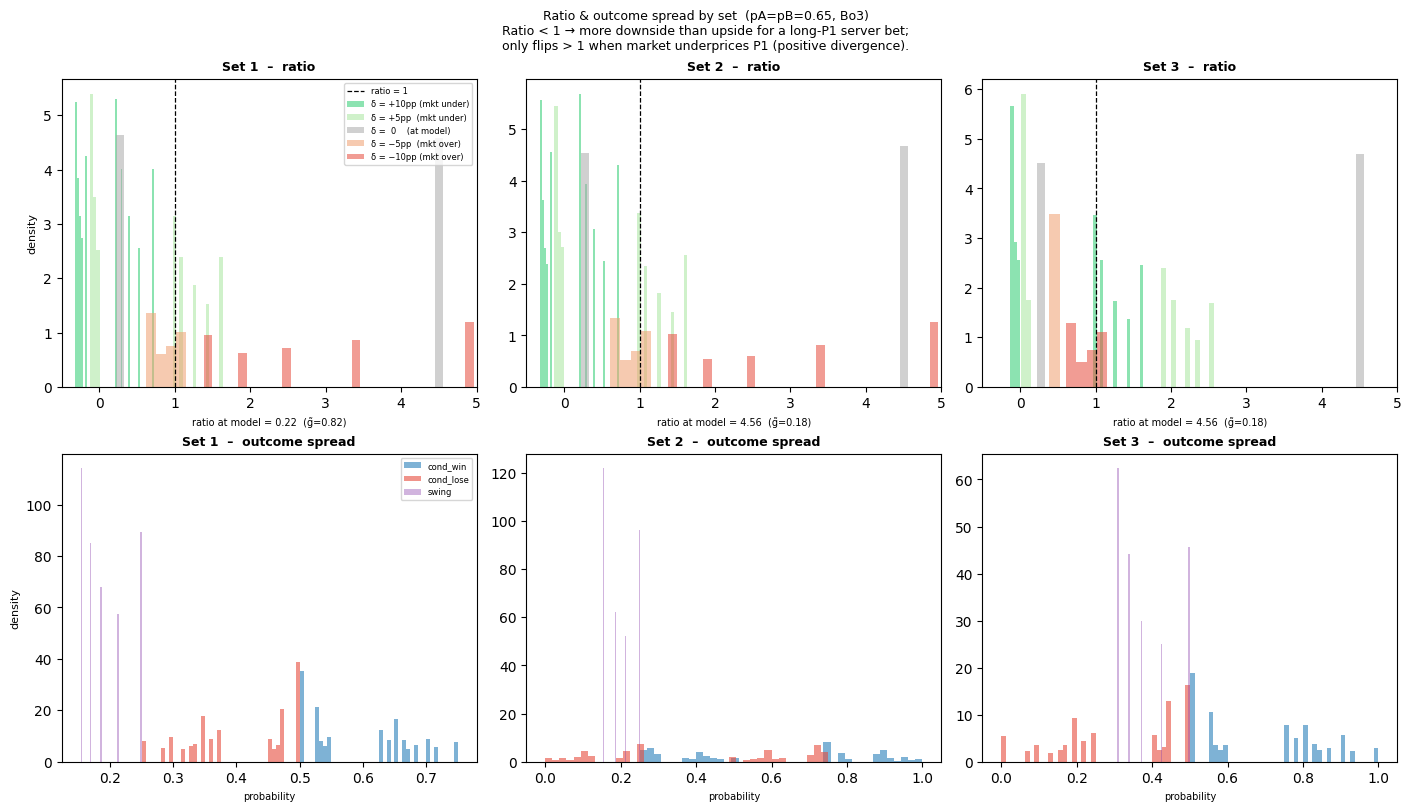

 set  med_swing  med_cond_win  med_cond_lose  med_g  ratio@model  ratio@δ+5pp  ratio@δ+10pp
   1      0.187         0.545          0.374   0.82        0.219       -0.020        -0.180
   2      0.187         0.750          0.500   0.18        4.559        0.977         0.202
   3      0.336         0.752          0.410   0.18        4.559        1.916         0.977


In [10]:
"""Ratio and E[ΔP] as a function of market divergence, by set."""
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_ex = pd.DataFrame(recs_ex, columns=["setno", "swing", "cond_win", "cond_lose", "g"])

# Model-implied current price (efficient: model = g*cw + (1-g)*cl)
df_ex["model"] = df_ex["g"] * df_ex["cond_win"] + (1 - df_ex["g"]) * df_ex["cond_lose"]

DELTAS = {
    "δ = +10pp (mkt under)": +0.10,
    "δ = +5pp  (mkt under)": +0.05,
    "δ =  0    (at model)":   0.00,
    "δ = −5pp  (mkt over)":  -0.05,
    "δ = −10pp (mkt over)":  -0.10,
}
COLORS = ["#2ecc71", "#a8e6a0", "#aaaaaa", "#f0a070", "#e74c3c"]

sets_bo3 = sorted(df_ex["setno"].unique())
n_sets = len(sets_bo3)

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs  = gridspec.GridSpec(2, n_sets, figure=fig)

for col, setno in enumerate(sets_bo3):
    sub = df_ex[df_ex.setno == setno].copy()

    # ── top row: ratio distribution by divergence ──────────────────────────
    ax_r = fig.add_subplot(gs[0, col])
    ax_r.axvline(1.0, color="k", lw=0.9, ls="--", label="ratio = 1")

    for (label, delta), color in zip(DELTAS.items(), COLORS):
        mkt = (sub["model"] + delta).clip(1e-3, 1 - 1e-3)
        denom = (mkt - sub["cond_lose"]).clip(1e-6)
        ratio = (sub["cond_win"] - mkt) / denom
        ax_r.hist(ratio.clip(-0.5, 6), bins=40, density=True,
                  alpha=0.55, color=color, label=label)

    ax_r.set_title(f"Set {setno}  –  ratio", fontsize=9, fontweight="bold")
    ax_r.set_xlabel("(cond_win − mkt) / (mkt − cond_lose)", fontsize=7)
    ax_r.set_xlim(-0.5, 5)
    if col == 0:
        ax_r.set_ylabel("density", fontsize=8)
        ax_r.legend(fontsize=6, loc="upper right")

    # ── bottom row: cond_win / cond_lose / swing distribution ──────────────
    ax_s = fig.add_subplot(gs[1, col])
    ax_s.hist(sub["cond_win"],  bins=40, density=True, alpha=0.6, color="#2980b9", label="cond_win")
    ax_s.hist(sub["cond_lose"], bins=40, density=True, alpha=0.6, color="#e74c3c", label="cond_lose")
    ax_s.hist(sub["swing"],     bins=40, density=True, alpha=0.4, color="#8e44ad", label="swing")
    ax_s.set_title(f"Set {setno}  –  outcome spread", fontsize=9, fontweight="bold")
    ax_s.set_xlabel("probability", fontsize=7)
    if col == 0:
        ax_s.set_ylabel("density", fontsize=8)
        ax_s.legend(fontsize=6)

    # annotate median swing and model-price ratio
    med_swing = sub["swing"].median()
    med_g     = sub["g"].median()
    med_ratio_at_model = (1 - med_g) / max(med_g, 1e-6)
    ax_r.set_xlabel(
        f"ratio at model = {med_ratio_at_model:.2f}  (g̃={med_g:.2f})", fontsize=7
    )

fig.suptitle(
    f"Ratio & outcome spread by set  (pA=pB={PA_EX}, Bo{BO_EX})\n"
    "Ratio < 1 → more downside than upside for a long-P1 server bet;\n"
    "only flips > 1 when market underprices P1 (positive divergence).",
    fontsize=9,
)
plt.show()

# ── Print median summary table ─────────────────────────────────────────────
rows = []
for setno in sets_bo3:
    sub = df_ex[df_ex.setno == setno]
    model_implied_ratio = (1 - sub["g"]) / sub["g"].clip(1e-6)
    rows.append({
        "set": setno,
        "med_swing":   round(sub["swing"].median(), 3),
        "med_cond_win": round(sub["cond_win"].median(), 3),
        "med_cond_lose": round(sub["cond_lose"].median(), 3),
        "med_g":        round(sub["g"].median(), 3),
        "ratio@model":  round(model_implied_ratio.median(), 3),
        "ratio@δ+5pp":  round(((sub["cond_win"] - (sub["model"]+0.05)) /
                                (sub["model"]+0.05 - sub["cond_lose"]).clip(1e-6)).median(), 3),
        "ratio@δ+10pp": round(((sub["cond_win"] - (sub["model"]+0.10)) /
                                (sub["model"]+0.10 - sub["cond_lose"]).clip(1e-6)).median(), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))